# Import Libraries

In [1]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Load Dataset

In [2]:
def get_project_root() -> Path:
    """Finds the root directory of the project using root markers."""
    current = Path(__file__).resolve() if '__file__' in globals() else Path.cwd().resolve()
    
    markers = [".git", "pyproject.toml", "requirements.txt", "uv.lock"]
    
    for parent in [current] + list(current.parents):
        if any((parent / marker).exists() for marker in markers):
            return parent
            
    if current.name == "Notebook":
        return current.parent
        
    return current


PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "Data"
MODEL_DIR = PROJECT_ROOT / "Model"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.text_preprocessing import (
    MODEL_TEXT_COLUMN, NGRAM_RANGE, MIN_DF,
    TEST_SIZE, RANDOM_STATE, LR_MAX_ITER
)


csv_path = DATA_DIR / "Cleaned IMDB Dataset.csv"
df = pd.read_csv(csv_path)

print("Project Root:", PROJECT_ROOT)
print("Data Path:", csv_path)
print("Data loaded successfully! Shape:", df.shape)

Project Root: D:\classical-nlp-streamlit-project\nlp-project
Data Path: D:\classical-nlp-streamlit-project\nlp-project\Data\Cleaned IMDB Dataset.csv
Data loaded successfully! Shape: (49582, 8)


# Train-Test Split

In [3]:
df.columns

Index(['review', 'sentiment', 'char_count', 'word_count',
       'char_count_no_spaces', 'sentence_count', 'clean_review',
       'lemmatized_text'],
      dtype='object')

In [4]:
# Settings come from utils/text_preprocessing.py so the app uses the same column
print("Training on column:", MODEL_TEXT_COLUMN)
x = df[MODEL_TEXT_COLUMN].fillna("")
y = df.sentiment

Training on column: lemmatized_text


In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = TEST_SIZE, random_state = RANDOM_STATE, stratify=y)

In [6]:
xtrain.head()

34595    one jehovah witness also work acute care medic...
17243    amongst standard one liner type action film ac...
9409     realty television crew assign cover small town...
21903    funniest scene movie probably saviour get meda...
10820    far too mainstream film set post colonial afri...
Name: lemmatized_text, dtype: object

In [7]:
xtest.head()

34940    wife watch dvr ing encore action past week wor...
18431    surprise much enjoy sure bite slow move part b...
4085     delightful movie very heart warm one not help ...
28000    la lupa mannara aka werewolf woman film highly...
3733     first movie not bad entertain least probably w...
Name: lemmatized_text, dtype: object

In [8]:
print(xtrain.shape, " ", ytrain.shape, " ", xtest.shape, " ", ytest.shape)

(39665,)   (39665,)   (9917,)   (9917,)


# CountVectorizer

Unigrams + bigrams (`NGRAM_RANGE`) so phrases like "not good" become features.

In [9]:
cv = CountVectorizer(ngram_range=NGRAM_RANGE, min_df=MIN_DF)
cv

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'


In [10]:
cv_xtrain = cv.fit_transform(xtrain)
cv_xtest = cv.transform(xtest)
print("Vocabulary size:", len(cv.vocabulary_))

Vocabulary size: 150139


# TF-IDF

In [11]:
tfidf = TfidfVectorizer(ngram_range=NGRAM_RANGE, min_df=MIN_DF, sublinear_tf=True)
tfidf

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [12]:
tfidf_xtrain = tfidf.fit_transform(xtrain)
tfidf_xtest = tfidf.transform(xtest)

LABELS = ["negative", "positive"]

def plot_confusion(model, xtest_vec, name):
    sns.heatmap(
        confusion_matrix(ytest, model.predict(xtest_vec), labels=LABELS),
        annot = True,
        fmt = "g",
        xticklabels=LABELS,
        yticklabels=LABELS,
        cbar=False
    )
    plt.title(f"Confusion Matrix — {name}", color = 'red', fontsize = 14)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_class_metrics(model, xtest_vec, name):
    report = classification_report(ytest, model.predict(xtest_vec), output_dict=True)
    metrics = pd.DataFrame(report).transpose().loc[LABELS, ["precision", "recall", "f1-score"]]
    ax = metrics.plot(kind="bar", figsize=(10,8))
    for x in ax.containers :
        ax.bar_label(x, color = 'red', fontsize = 10, padding = 3, fmt = '%.2f')
    plt.title(f"Classification Metrics — {name}", color = 'red', fontsize = 18)
    plt.ylabel("Score", color = 'red', fontsize = 14)
    plt.xlabel("Sentiment", color = 'red', fontsize = 14)
    plt.xticks(rotation=0)
    plt.show()

# CountVectorizer + Logistic Regression

In [13]:
cv_lr = LogisticRegression(max_iter=LR_MAX_ITER)

cv_lr.fit(cv_xtrain, ytrain)
print(classification_report(ytest, cv_lr.predict(cv_xtest)))

              precision    recall  f1-score   support

    negative       0.90      0.90      0.90      4940
    positive       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



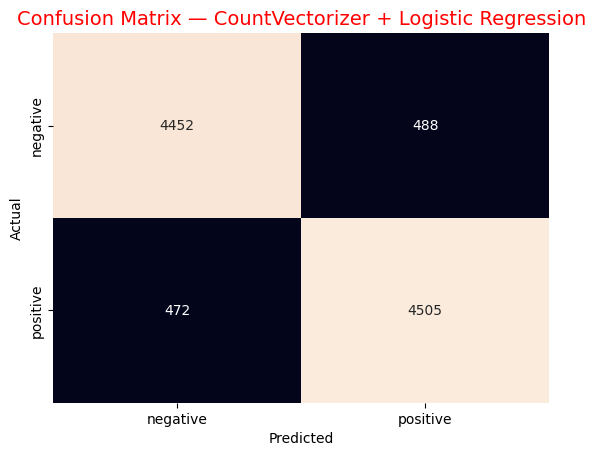

In [14]:
plot_confusion(cv_lr, cv_xtest, "CountVectorizer + Logistic Regression")

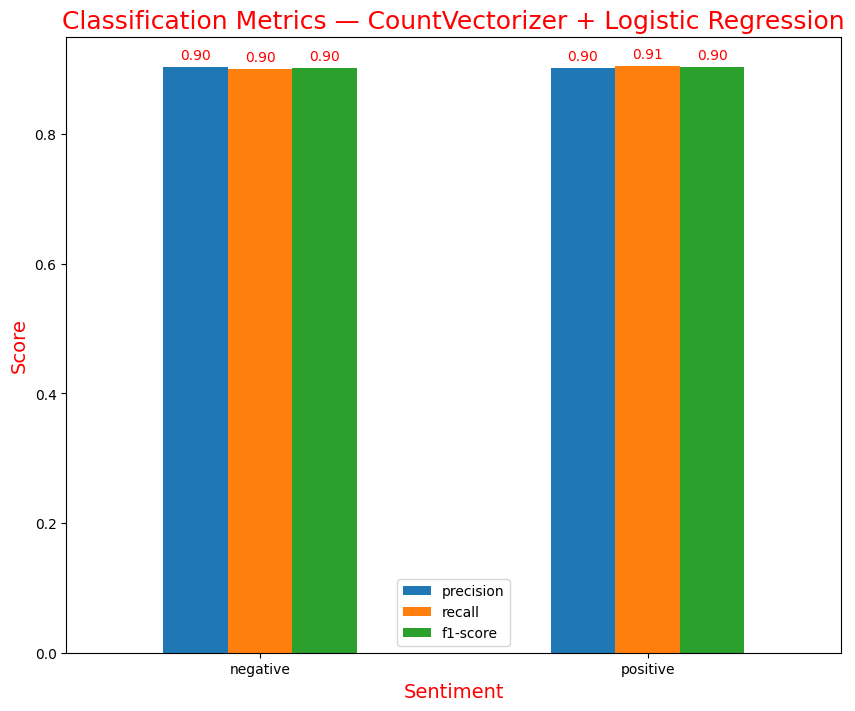

In [15]:
plot_class_metrics(cv_lr, cv_xtest, "CountVectorizer + Logistic Regression")

# CountVectorizer + Naive Bayes

In [16]:
cv_mnb = MultinomialNB() 
cv_mnb.fit(cv_xtrain, ytrain)
print(classification_report(ytest, cv_mnb.predict(cv_xtest)))

              precision    recall  f1-score   support

    negative       0.88      0.89      0.88      4940
    positive       0.89      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



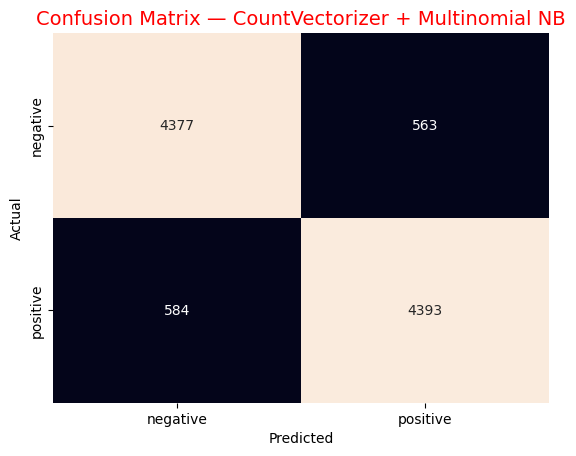

In [17]:
plot_confusion(cv_mnb, cv_xtest, "CountVectorizer + Multinomial NB")

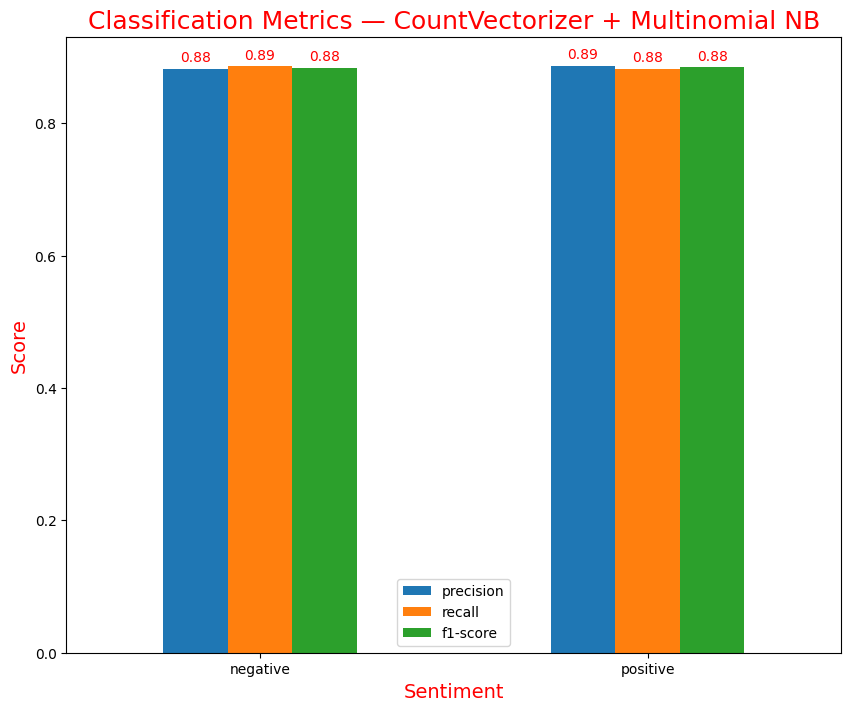

In [18]:
plot_class_metrics(cv_mnb, cv_xtest, "CountVectorizer + Multinomial NB")

# TF-IDF + Logistic Regression

In [19]:
tfidf_lr = LogisticRegression(max_iter=LR_MAX_ITER)
tfidf_lr.fit(tfidf_xtrain, ytrain)
print(classification_report(ytest, tfidf_lr.predict(tfidf_xtest)))

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



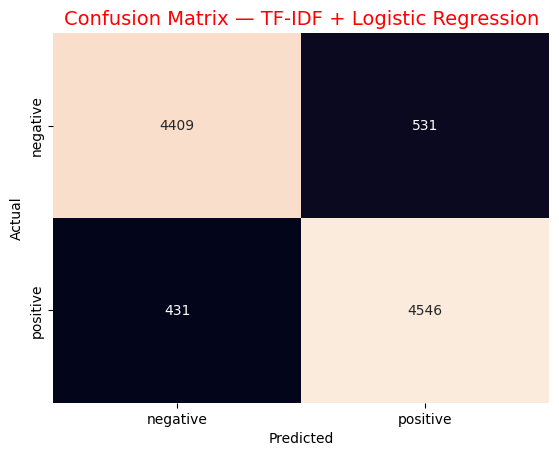

In [20]:
plot_confusion(tfidf_lr, tfidf_xtest, "TF-IDF + Logistic Regression")

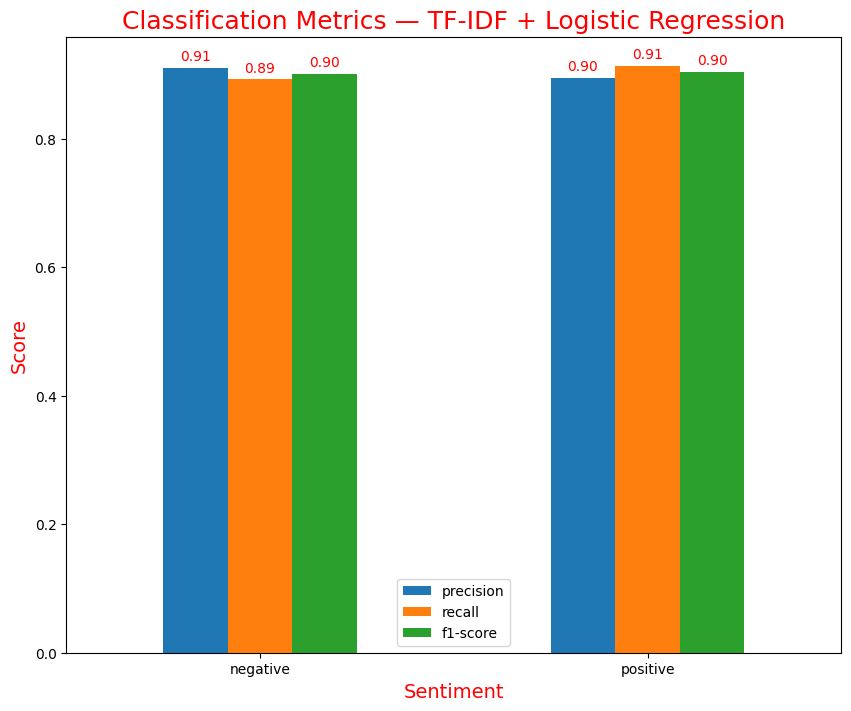

In [21]:
plot_class_metrics(tfidf_lr, tfidf_xtest, "TF-IDF + Logistic Regression")

# TF-IDF + Naive Bayes

In [22]:
tfidf_mnb = MultinomialNB() 
tfidf_mnb.fit(tfidf_xtrain, ytrain)
print(classification_report(ytest, tfidf_mnb.predict(tfidf_xtest)))

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      4940
    positive       0.89      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



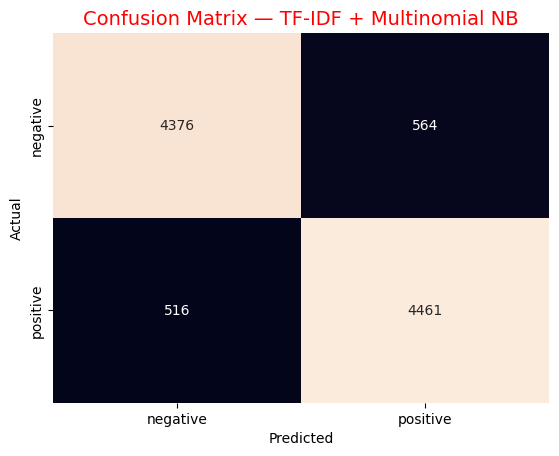

In [23]:
plot_confusion(tfidf_mnb, tfidf_xtest, "TF-IDF + Multinomial NB")

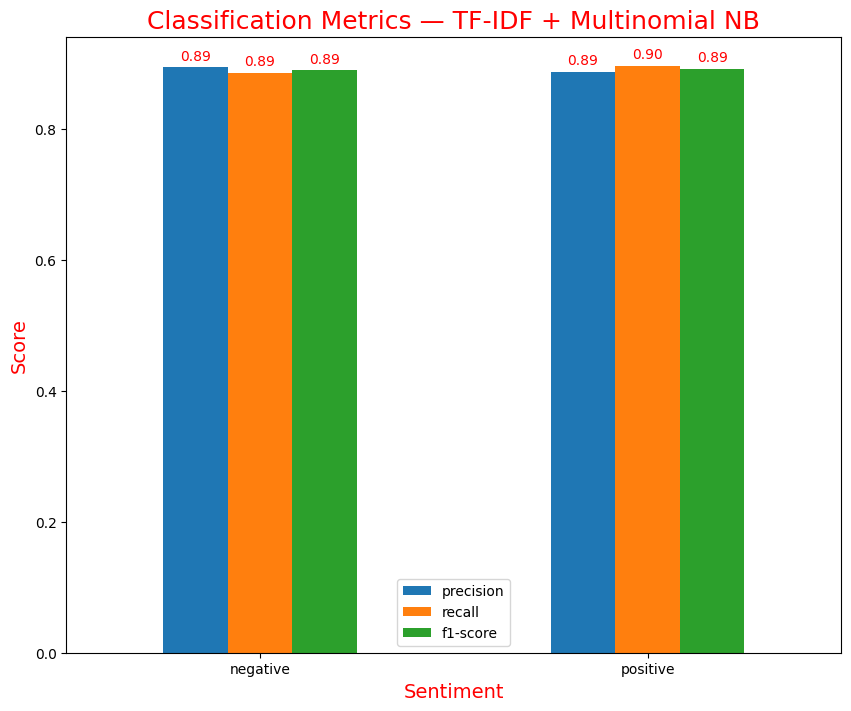

In [24]:
plot_class_metrics(tfidf_mnb, tfidf_xtest, "TF-IDF + Multinomial NB")

# Visualization

## N-gram Visualization

N-grams are counted on `clean_review` without extra stopword removal, so negations such as "not" are kept (same as the Streamlit EDA page).

### Top Bigrams

In [25]:
vectorizer = CountVectorizer(
    ngram_range=(2, 2)
)

X_bigram = vectorizer.fit_transform(
    df["clean_review"]
)

bigram_counts = X_bigram.sum(axis=0).A1

bigram_names = vectorizer.get_feature_names_out()

bigram_freq = pd.DataFrame({
    "bigram": bigram_names,
    "count": bigram_counts
})

bigram_freq = bigram_freq.sort_values(
    "count",
    ascending=False
).head(20)

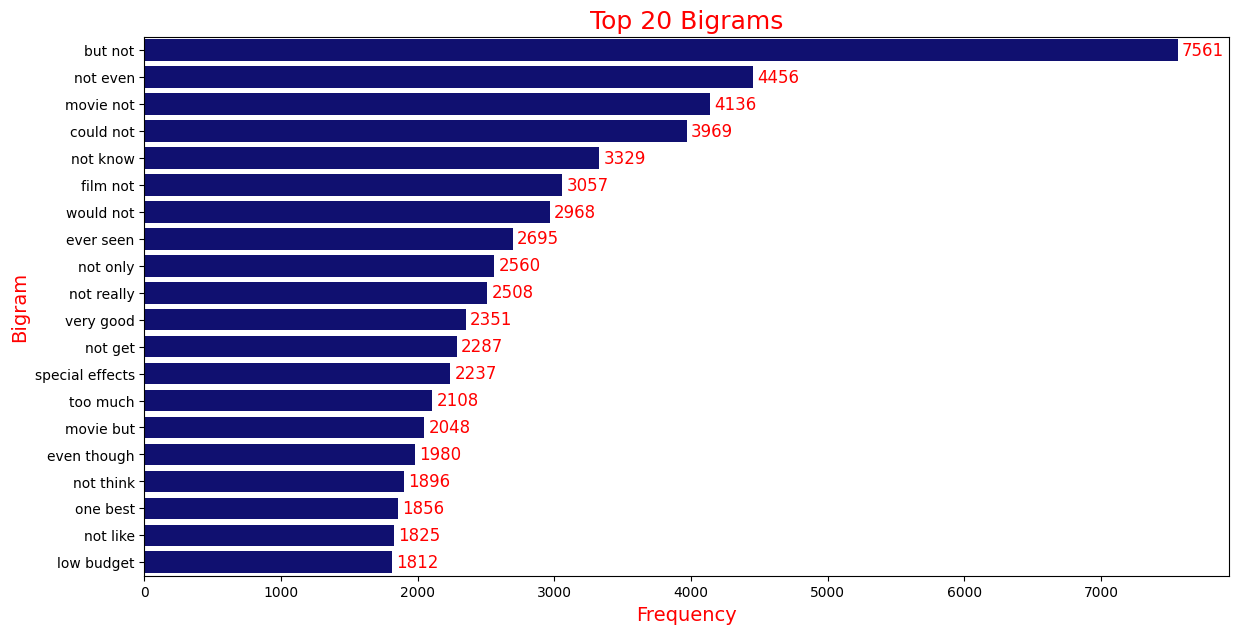

In [26]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=bigram_freq,
    x="count",
    y="bigram",
    color = 'navy'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

plt.title("Top 20 Bigrams", color = 'red', fontsize = 18)
plt.xlabel("Frequency", color = 'red', fontsize = 14)
plt.ylabel("Bigram", color = 'red', fontsize = 14)

plt.show()

### Top Trigrams

In [27]:
vectorizer = CountVectorizer(
    ngram_range=(3,3),
    min_df=5
)

X_trigram = vectorizer.fit_transform(
    df["clean_review"]
)

trigram_counts = X_trigram.sum(axis=0).A1

trigram_names = vectorizer.get_feature_names_out()

trigram_freq = pd.DataFrame({
    "trigram": trigram_names,
    "count": trigram_counts
})

trigram_freq = trigram_freq.sort_values(
    "count",
    ascending=False
).head(20)

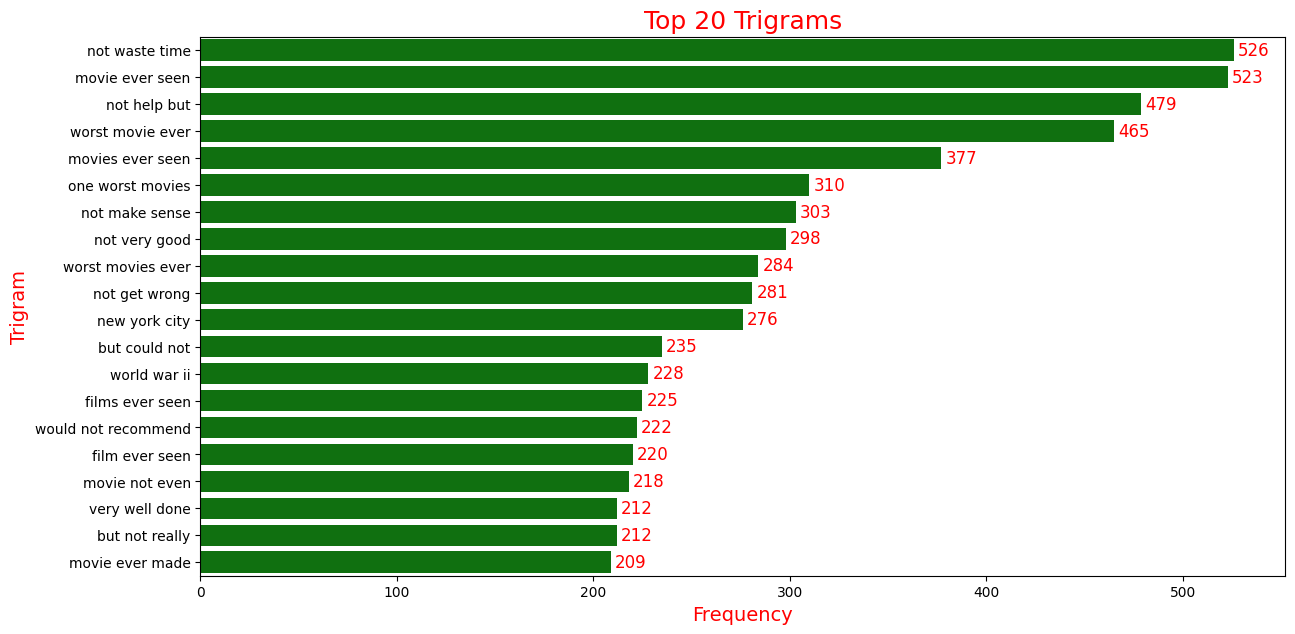

In [28]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=trigram_freq,
    x="count",
    y="trigram",
    color = 'green'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

plt.title("Top 20 Trigrams", color = 'red', fontsize = 18)
plt.xlabel("Frequency", color = 'red', fontsize = 14)
plt.ylabel("Trigram", color = 'red', fontsize = 14)

plt.show()

### Positive vs Negative Bigrams

In [29]:
def get_top_bigrams(texts, top_n=20):

    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words=None
    )

    X = vectorizer.fit_transform(texts)

    counts = X.sum(axis=0).A1
    bigrams = vectorizer.get_feature_names_out()

    bigram_df = pd.DataFrame({
        "bigram": bigrams,
        "count": counts
    })

    return (
        bigram_df
        .sort_values(
            "count",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

In [30]:
positive_reviews = df[
    df["sentiment"] == "positive"
]["clean_review"]

negative_reviews = df[
    df["sentiment"] == "negative"
]["clean_review"]

In [31]:
positive_bigrams = get_top_bigrams(
    positive_reviews,
    top_n=20
)

negative_bigrams = get_top_bigrams(
    negative_reviews,
    top_n=20
)

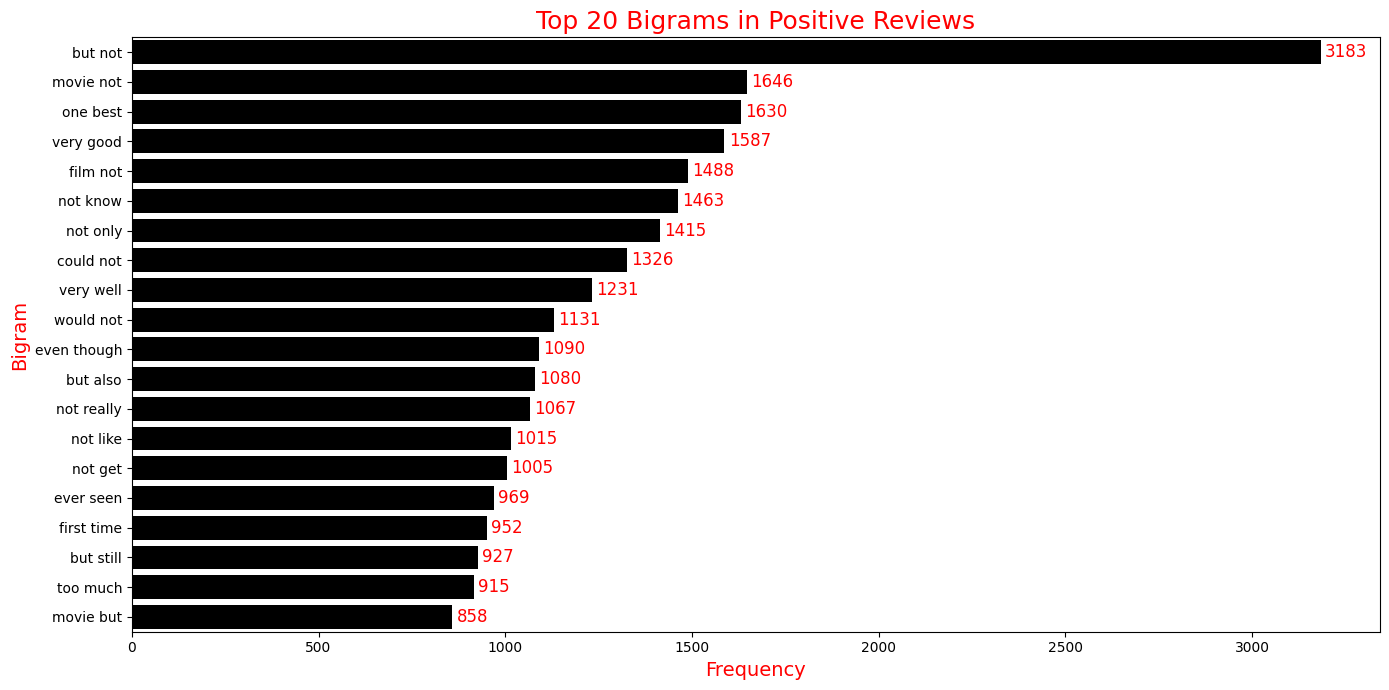

In [32]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=positive_bigrams,
    x="count",
    y="bigram",
    color = 'k'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

plt.title("Top 20 Bigrams in Positive Reviews", color = 'red', fontsize = 18)
plt.xlabel("Frequency", color = 'red', fontsize = 14)
plt.ylabel("Bigram", color = 'red', fontsize = 14)

plt.tight_layout()
plt.show()

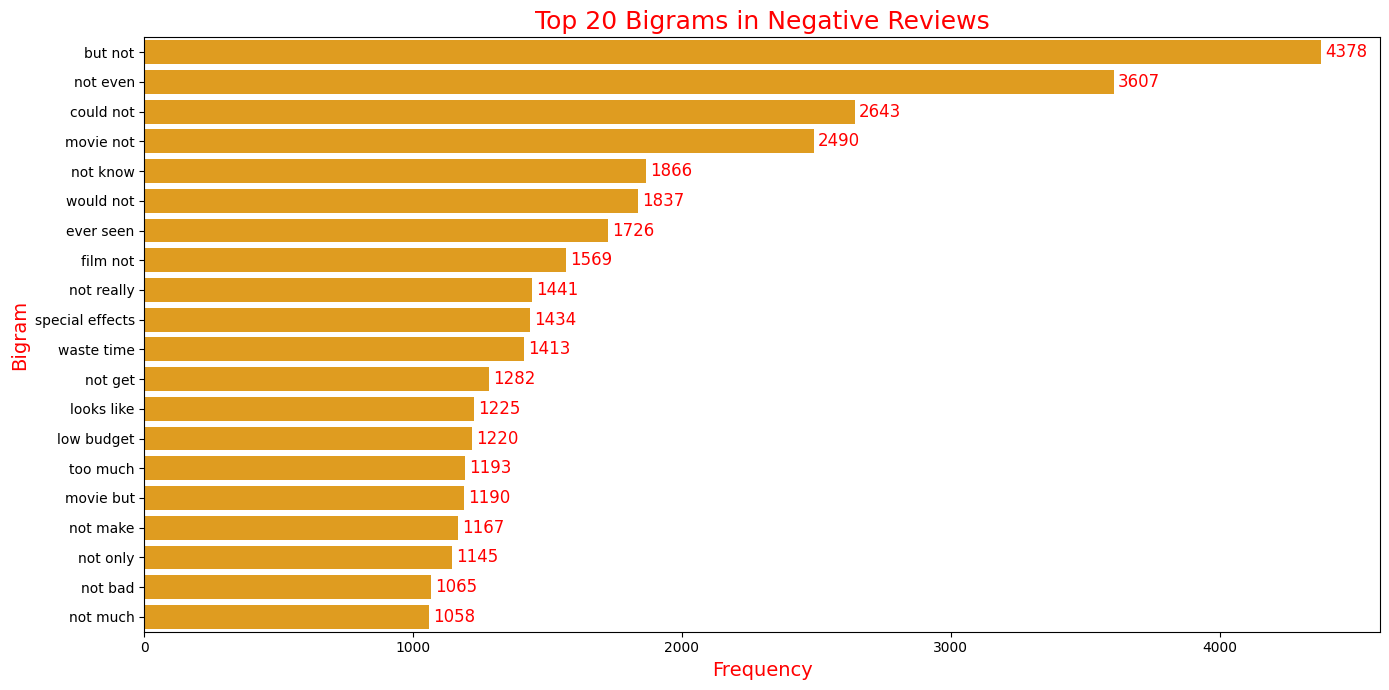

In [33]:
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=negative_bigrams,
    x="count",
    y="bigram",
    color = 'orange'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

plt.title("Top 20 Bigrams in Negative Reviews", color = 'red', fontsize = 18)
plt.xlabel("Frequency", color = 'red', fontsize = 14)
plt.ylabel("Bigram", color = 'red', fontsize = 14)

plt.tight_layout()
plt.show()

### Positive vs Negative Side-by-Side

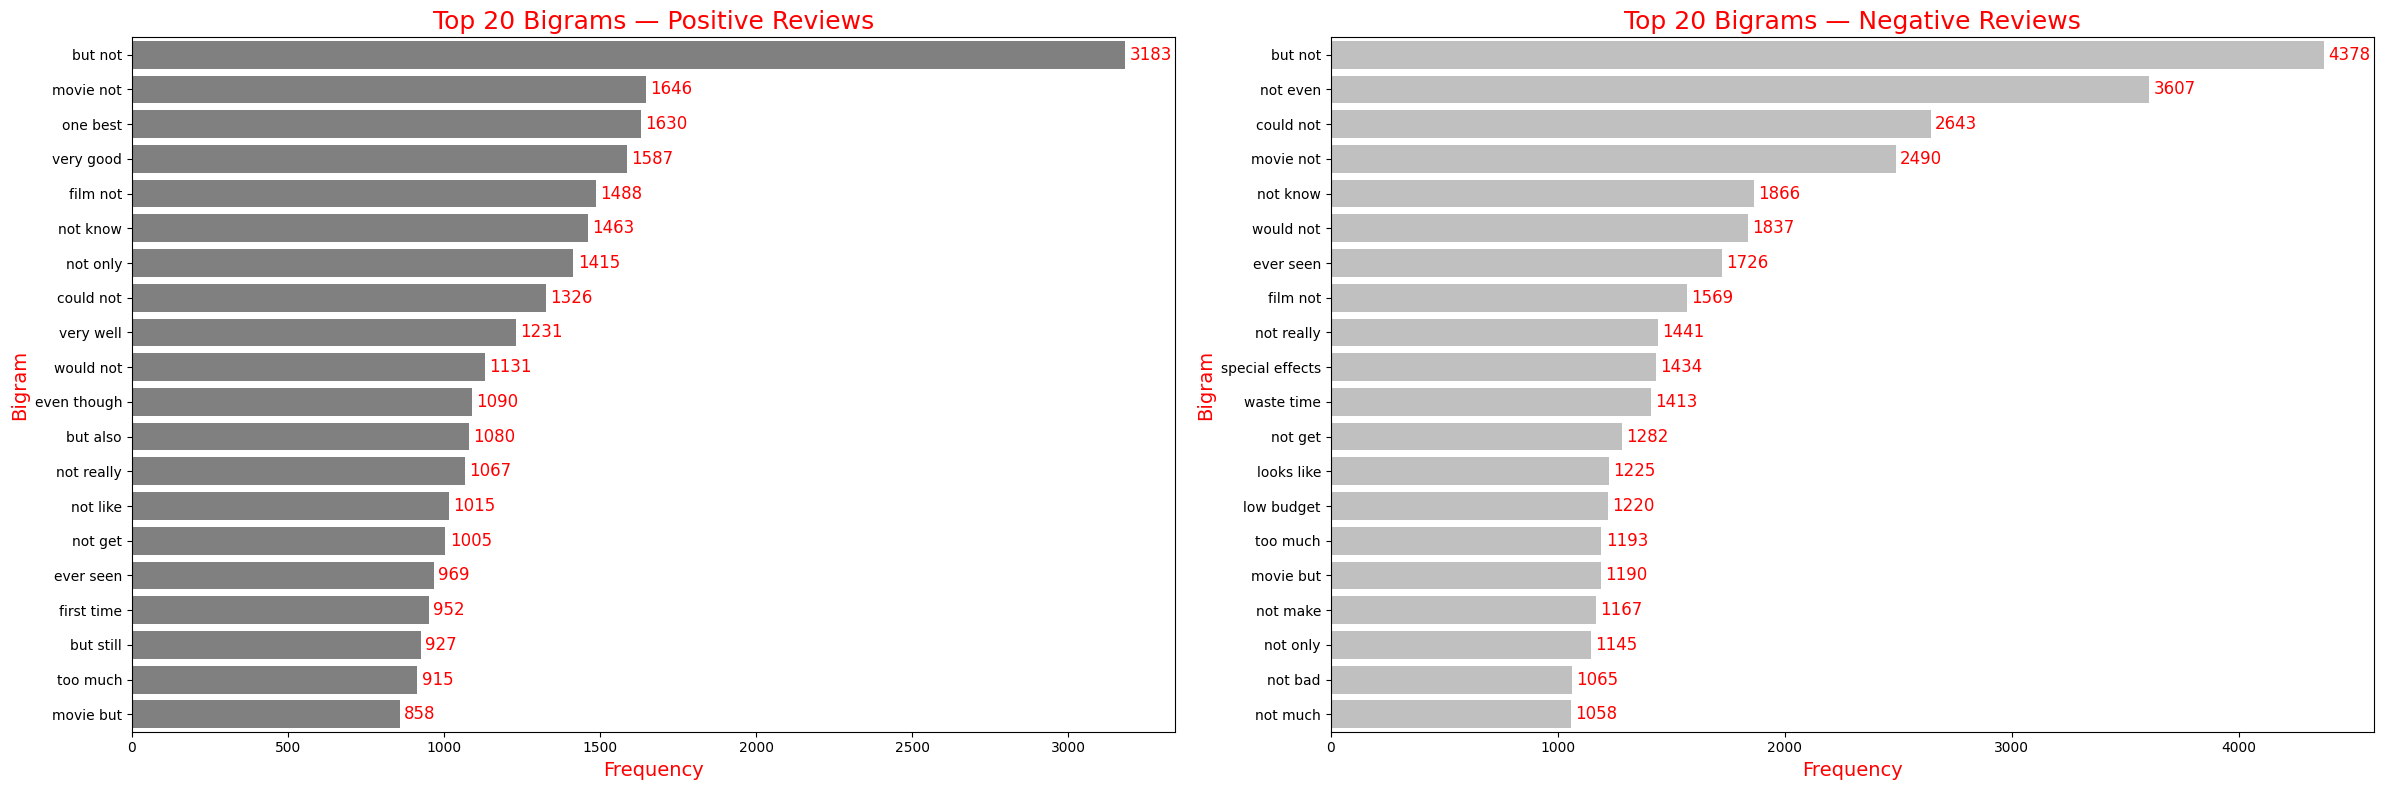

In [34]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 8)
)

# Positive
ax = sns.barplot(
    data=positive_bigrams,
    x="count",
    y="bigram",
    ax=axes[0],
    color = 'gray'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

axes[0].set_title(
    "Top 20 Bigrams — Positive Reviews", color = 'red', fontsize = 18
)

axes[0].set_xlabel("Frequency", color = 'red', fontsize = 14)
axes[0].set_ylabel("Bigram", color = 'red', fontsize = 14)


# Negative
ax = sns.barplot(
    data=negative_bigrams,
    x="count",
    y="bigram",
    ax=axes[1],
    color = 'silver'
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3)

axes[1].set_title(
    "Top 20 Bigrams — Negative Reviews", color = 'red', fontsize = 18
)

axes[1].set_xlabel("Frequency", color = 'red', fontsize = 14)
axes[1].set_ylabel("Bigram", color = 'red', fontsize = 14)


plt.tight_layout()
plt.show()

## TF-IDF Visualization

In [35]:
features = tfidf.get_feature_names_out()

mean_tfidf = tfidf_xtrain.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "feature": features,
    "score": mean_tfidf
})

tfidf_df = (
    tfidf_df
    .sort_values(
        "score",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

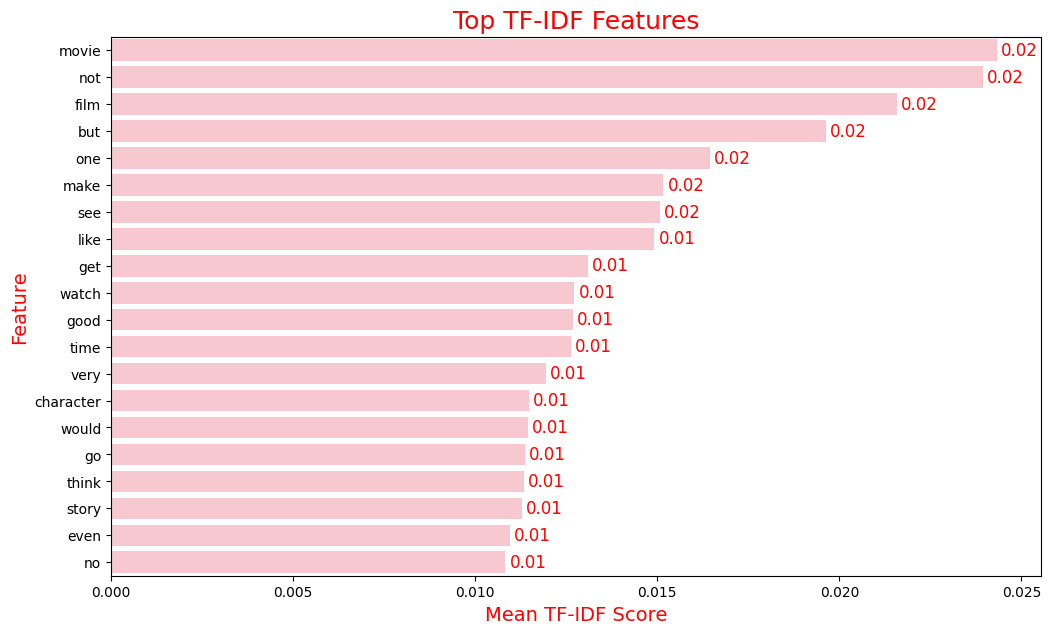

In [36]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=tfidf_df,
    x="score",
    y="feature",
    color = "pink"
)

for x in ax.containers :
    ax.bar_label(x, color = 'red', fontsize = 12, padding = 3, fmt = "%.2f")

plt.title("Top TF-IDF Features", color = 'red', fontsize = 18)
plt.xlabel("Mean TF-IDF Score", color = 'red', fontsize = 14)
plt.ylabel("Feature", color = 'red', fontsize = 14)

plt.show()

## Model Comparison

In [37]:
all_models = {
    "CountVectorizer + Logistic Regression": (cv_lr, cv_xtest),
    "TF-IDF + Logistic Regression": (tfidf_lr, tfidf_xtest),
    "CountVectorizer + Multinomial NB": (cv_mnb, cv_xtest),
    "TF-IDF + Multinomial NB": (tfidf_mnb, tfidf_xtest),
}

rows = []
for name, (model, xtest_vec) in all_models.items():
    pred = model.predict(xtest_vec)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(ytest, pred),
        "Precision": precision_score(ytest, pred, pos_label="positive"),
        "Recall": recall_score(ytest, pred, pos_label="positive"),
        "F1": f1_score(ytest, pred, pos_label="positive"),
    })

model_results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1
0,CountVectorizer + Logistic Regression,0.9032,0.9023,0.9052,0.9037
1,TF-IDF + Logistic Regression,0.9030,0.8954,0.9134,0.9043
2,TF-IDF + Multinomial NB,0.8911,0.8878,0.8963,0.8920
3,CountVectorizer + Multinomial NB,0.8843,0.8864,0.8827,0.8845


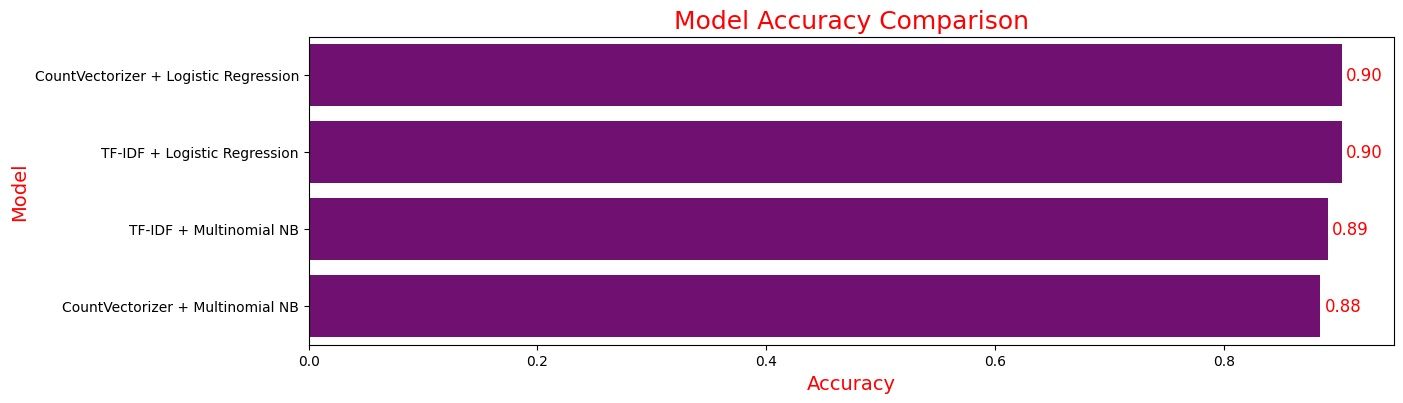

In [38]:
plt.figure(figsize=(14, 4))

ax = sns.barplot(
    data=model_results,
    x="Accuracy",
    y="Model",
    color = 'purple'
)

for x in ax.containers :
    ax.bar_label(x, color ='red', fontsize = 12, padding = 3, fmt = "%.2f")

plt.title("Model Accuracy Comparison", color = 'red', fontsize = 18)
plt.xlabel("Accuracy", color = 'red', fontsize = 14)
plt.ylabel("Model", color = 'red', fontsize = 14)

plt.show()

## ROC Curve and Precision-Recall Curve (all models)

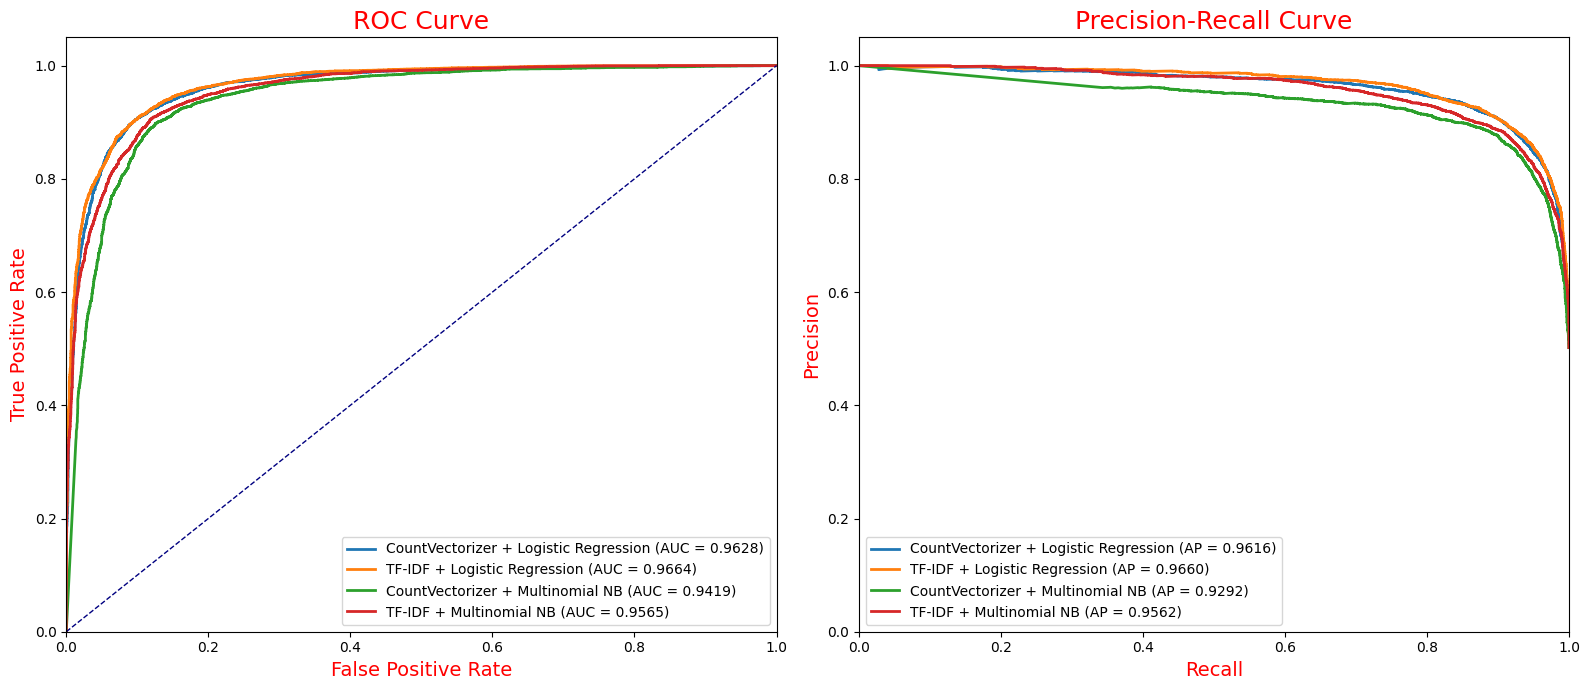

In [39]:
pos_label = 'positive'
y_true_binary = (ytest == pos_label).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for name, (model, xtest_vec) in all_models.items():
    pos_idx = list(model.classes_).index(pos_label)
    y_scores = model.predict_proba(xtest_vec)[:, pos_idx]   # each model gets its OWN features

    fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
    precision, recall, _ = precision_recall_curve(y_true_binary, y_scores)

    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
    axes[1].plot(recall, precision, lw=2, label=f"{name} (AP = {average_precision_score(y_true_binary, y_scores):.4f})")

axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', color = 'red', fontsize = 14)
axes[0].set_ylabel('True Positive Rate', color = 'red', fontsize = 14)
axes[0].set_title('ROC Curve', color = 'red', fontsize = 18)
axes[0].legend(loc='lower right')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', color = 'red', fontsize = 14)
axes[1].set_ylabel('Precision', color = 'red', fontsize = 14)
axes[1].set_title('Precision-Recall Curve', color = 'red', fontsize = 18)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Save Models & Vectorizers

In [40]:
MODELS_DIR = MODEL_DIR / "models"
VECTORIZER_DIR = MODEL_DIR / "vectorizer"

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VECTORIZER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    cv,
    VECTORIZER_DIR / "count_vectorizer.joblib",
    compress=3
)

joblib.dump(
    tfidf,
    VECTORIZER_DIR / "tfidf_vectorizer.joblib",
    compress=3
)

joblib.dump(
    cv_lr,
    MODELS_DIR / "cv_logistic_regression.joblib",
    compress=3
)

joblib.dump(
    cv_mnb,
    MODELS_DIR / "cv_multinomial_nb.joblib",
    compress=3
)

joblib.dump(
    tfidf_lr,
    MODELS_DIR / "tfidf_logistic_regression.joblib",
    compress=3
)

joblib.dump(
    tfidf_mnb,
    MODELS_DIR / "tfidf_multinomial_nb.joblib",
    compress=3
)

model_results.to_json(MODEL_DIR / "model_metrics.json", orient="records", indent=2)

import sklearn
print("scikit-learn version:", sklearn.__version__, "(pin this version in pyproject.toml)")
print("Models saved to:", MODELS_DIR)
print("Vectorizers saved to:", VECTORIZER_DIR)

scikit-learn version: 1.7.2 (pin this version in pyproject.toml)
Models saved to: D:\classical-nlp-streamlit-project\nlp-project\Model\models
Vectorizers saved to: D:\classical-nlp-streamlit-project\nlp-project\Model\vectorizer
